In [1]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
files=glob.glob('../data/*_clean.csv')
all_countries=[]

In [3]:
for f in files:
    temp_df=pd.read_csv(f)
    all_countries.append(temp_df)


In [4]:
combined=pd.concat(all_countries, ignore_index=True)

In [5]:
combined

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,COUNTRY,DATE,MONTH
0,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20535,2026,86,27.63,30.65,25.66,4.99,2.96,77.48,1.57,2.40,100.73,17.72,Tanzania,2026-03-27,3
20536,2026,87,27.51,31.23,24.84,6.39,1.65,77.72,1.36,1.79,100.61,17.59,Tanzania,2026-03-28,3
20537,2026,88,27.74,31.21,25.33,5.88,1.28,77.35,1.53,2.01,100.42,17.81,Tanzania,2026-03-29,3
20538,2026,89,27.83,31.29,25.31,5.98,0.92,76.50,1.64,2.15,100.43,17.72,Tanzania,2026-03-30,3


In [6]:
combined['COUNTRY'].value_counts()

COUNTRY
Ethiopia    4108
Kenya       4108
Nigeria     4108
Sudan       4108
Tanzania    4108
Name: count, dtype: int64

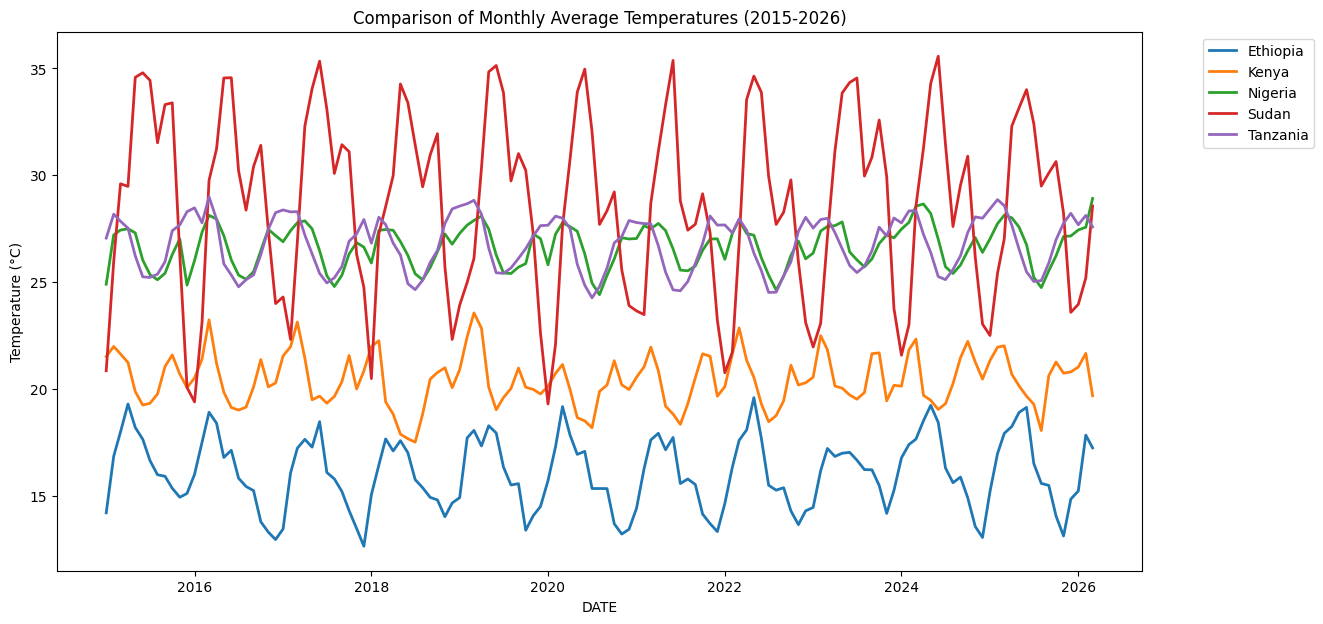

In [7]:
combined['DATE'] = pd.to_datetime(combined['DATE'])
monthly_combined=combined.set_index('DATE').groupby(['COUNTRY'], observed=False).resample('MS')['T2M'].mean().reset_index()
plt.figure(figsize=(14,7))
sns.lineplot(data=monthly_combined, x='DATE', y='T2M', hue='COUNTRY', linewidth=2)
plt.title("Comparison of Monthly Average Temperatures (2015-2026)")
plt.ylabel("Temperature (°C)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [8]:
summary_table=combined.groupby('COUNTRY', observed=False).agg(
    median_t2m_per_country=('T2M', 'median'),
    average_t2m_per_country=('T2M', 'mean'),
    std_t2m_per_country=('T2M', 'std')

)
summary_table

,median_t2m_per_country,average_t2m_per_country,std_t2m_per_country
COUNTRY,,,
Ethiopia,16.04,16.068500,1.898050
Kenya,20.36,20.427600,1.440824
Nigeria,26.82,26.656928,1.123335
Sudan,29.16,28.759007,4.681305
Tanzania,26.99,26.802422,1.325388


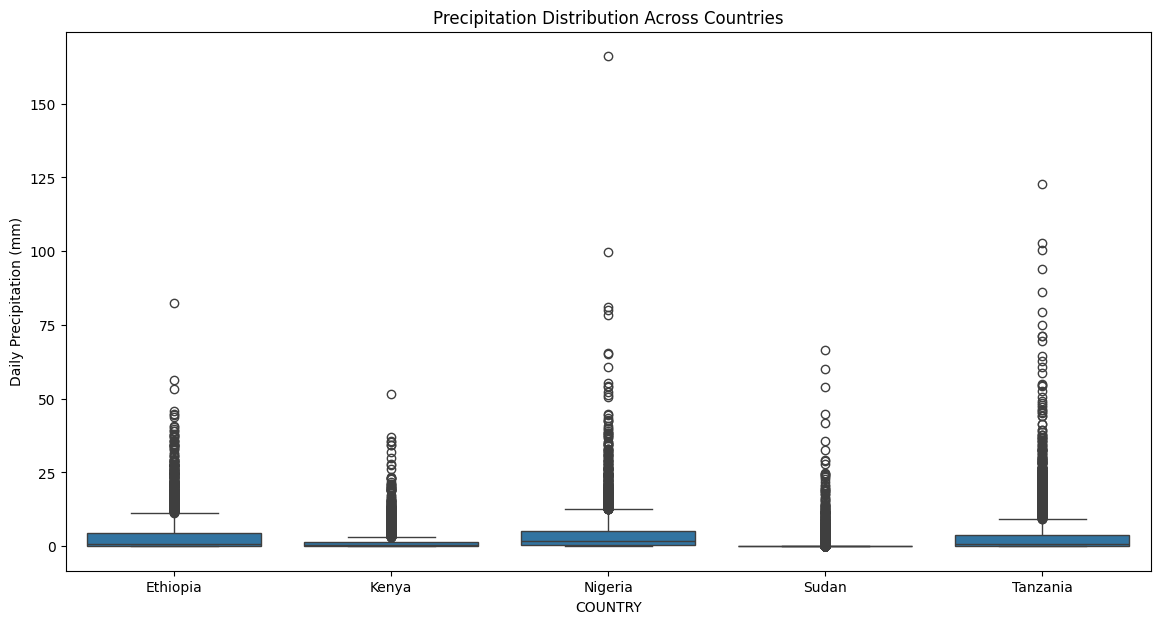

In [9]:
plt.figure(figsize=(14,7))
sns.boxplot(data=combined, x='COUNTRY', y='PRECTOTCORR')
plt.title('Precipitation Distribution Across Countries')
plt.ylabel('Daily Precipitation (mm)')
plt.show()

In [11]:
summary_table_PRECTOTCORR=combined.groupby('COUNTRY', observed=False).agg(
    median_prec_per_country=('PRECTOTCORR', 'median'),
    average_prec_per_country=('PRECTOTCORR', 'mean'),
    std_prec_per_country=('PRECTOTCORR', 'std')

)
summary_table_PRECTOTCORR

,median_prec_per_country,average_prec_per_country,std_prec_per_country
COUNTRY,,,
Ethiopia,0.82,3.633795,6.289061
Kenya,0.38,1.468162,3.180228
Nigeria,1.84,4.213914,7.266742
Sudan,0.00,0.643875,3.057672
Tanzania,0.64,3.740256,8.003947


In [14]:
combined.loc[combined['T2M_MAX']>35]

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,COUNTRY,DATE,MONTH
12324,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
12346,2015,23,25.48,35.81,16.49,19.32,0.0,24.32,2.75,3.58,96.45,5.20,Sudan,2015-01-23,1
12347,2015,24,25.64,35.77,16.79,18.98,0.0,28.78,2.67,3.77,96.31,5.79,Sudan,2015-01-24,1
12348,2015,25,25.65,36.22,17.08,19.14,0.0,22.95,2.87,3.98,96.43,4.43,Sudan,2015-01-25,1
12349,2015,26,25.81,36.34,16.92,19.42,0.0,22.50,3.07,4.15,96.47,4.37,Sudan,2015-01-26,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16425,2026,84,32.53,40.42,24.70,15.72,0.0,17.28,2.52,3.72,95.72,5.31,Sudan,2026-03-25,3
16428,2026,87,28.73,36.61,21.34,15.27,0.0,9.75,3.21,4.40,96.35,2.44,Sudan,2026-03-28,3
16429,2026,88,30.06,38.89,21.15,17.74,0.0,11.63,2.41,3.87,96.10,3.12,Sudan,2026-03-29,3
16430,2026,89,32.50,41.53,23.61,17.92,0.0,14.06,2.81,4.87,95.93,4.18,Sudan,2026-03-30,3
